#  Task 3: Fake News Detection

**Goal:** Classify news articles as **Real** or **Fake** based on text content  
**Dataset:** `ErfanMoosaviMonazzah/fake-news-detection-dataset-English` (Hugging Face)  
**Topics:**   TF-IDF | Text Preprocessing  



## Step 1: Installed & Imported Libraries

In [ ]:
!pip install nltk scikit-learn pandas numpy matplotlib seaborn wordcloud datasets --quiet

In [12]:
import warnings
warnings.filterwarnings('ignore')

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from datasets import load_dataset

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay



In [13]:
# Download NLTK data
for resource in ['stopwords', 'wordnet', 'omw-1.4']:
    nltk.download(resource, quiet=True)

plt.style.use('seaborn-v0_8-whitegrid')
print('Libraries ready!')

Libraries ready!



## Step 2: Loading the Dataset from hugging face 

In [15]:
# Load directly from Hugging Face models 
dataset = load_dataset('ErfanMoosaviMonazzah/fake-news-detection-dataset-English')

# Convert splits to DataFrames
df_train = pd.DataFrame(dataset['train'])
df_val   = pd.DataFrame(dataset['validation'])
df_test  = pd.DataFrame(dataset['test'])


In [16]:
# Combine all splits so we control our own split later
df = pd.concat([df_train, df_val, df_test], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)


In [17]:
# label: 0 = Fake, 1 = Real
print(f'Total articles : {len(df):,}')
print(f'Fake articles  : {(df.label == 0).sum():,}')
print(f'Real articles  : {(df.label == 1).sum():,}')
print(f'Columns        : {list(df.columns)}')



Total articles : 44,267
Fake articles  : 22,851
Real articles  : 21,416
Columns        : ['Unnamed: 0', 'title', 'text', 'subject', 'date', 'label']


In [18]:
df.head(3)

,Unnamed: 0,title,text,subject,date,label
0,20220,"PRIORITIES: AS VETS LAY DYING, WAITING For Med...",Is it any wonder veterans are getting behind D...,left-news,"Jul 26, 2016",0
1,19778,DEMOCRAT THUGS VANDALIZE REPUBLICAN Offices Ac...,NC REPUBLICAN HEADQUARTERS Firebombed By The T...,left-news,"Oct 19, 2016",0
2,4451,Ryan says tax reform could take longer than he...,U.S. House of Representatives Speaker Paul Rya...,politicsNews,"April 5, 2017",1


---
## Step 3: Exploratory Data Analysis EDA 

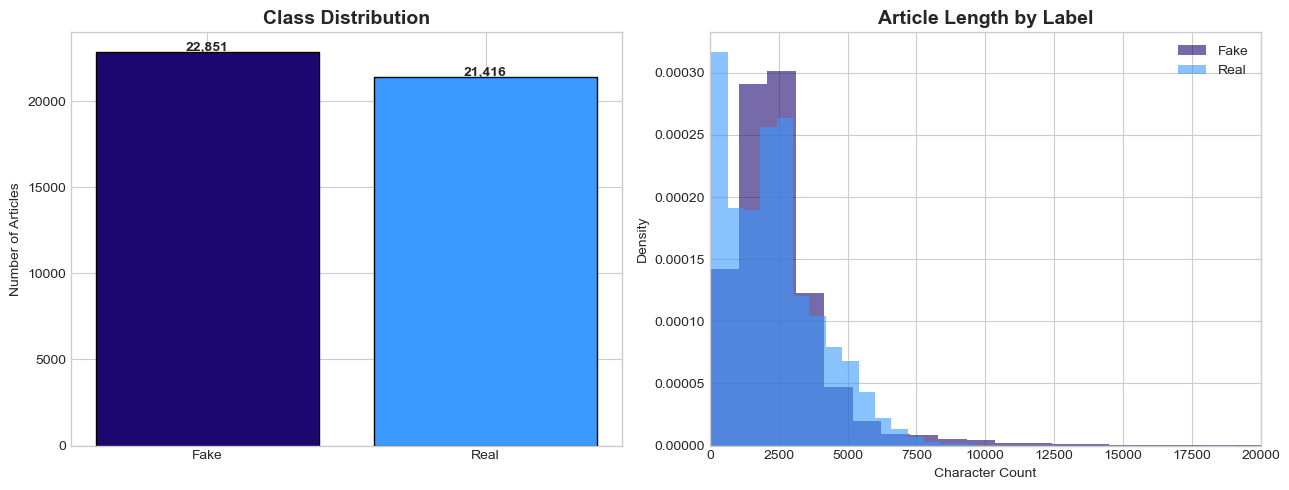

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Class distribution
counts = df['label'].value_counts()
axes[0].bar(['Fake', 'Real'], counts.values, color=['#1C0770', '#3A9AFF'], edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Articles')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

# Article length distribution
df['text_length'] = df['text'].fillna('').apply(len)
for label, color, name in [(0, '#1C0770', 'Fake'), (1, '#3A9AFF', 'Real')]:
    axes[1].hist(df[df['label'] == label]['text_length'], bins=50,
                 alpha=0.6, color=color, label=name, density=True)
axes[1].set_title('Article Length by Label', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Character Count')
axes[1].set_ylabel('Density')
axes[1].set_xlim(0, 20000)
axes[1].legend()

plt.tight_layout()
plt.savefig('eda.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 4: Text Preprocessing

We combine **title + text**, then clean: lowercase == remove noise == remove stopwords == lemmatize

In [21]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))


def preprocess(text):
    """Clean, remove stopwords, and lemmatize text."""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)   
    # remove URLs
    text = re.sub(r'[^a-z\s]', ' ', text)           
    # keep letters only
    text = re.sub(r'\s+', ' ', text).strip()        
    # clean whitespace

    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens
              if w not in stop_words and len(w) > 2]

    return ' '.join(tokens)


# The HF dataset has a single 'text' column — use it directly
print('Preprocessing articles...')
df['content_clean'] = df['text'].apply(preprocess)
print(' Done!')



Preprocessing articles...
 Done!


In [22]:
# Show before/after
print('\nOriginal :', df['text'].iloc[0][:150])
print('\n')
print('Cleaned  :', df['content_clean'].iloc[0][:150])


Original : Is it any wonder veterans are getting behind Donald J. Trump in huge numbers? Isn t it about time we took care of our veterans the way they deserve to


Cleaned  : wonder veteran getting behind donald trump huge number time took care veteran way deserve taken care obama administration never dysfunctional corrupt 


---
## Step 5: TF-IDF Vectorization & Train/Test Split

In [23]:
# Split first, then vectorize — avoids data leakage
X = df['content_clean']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),   # unigrams + bigrams
    min_df=3,
    sublinear_tf=True     # log scaling
)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec  = tfidf.transform(X_test)

print(f'Train size   : {X_train_vec.shape[0]:,} articles')
print(f'Test size    : {X_test_vec.shape[0]:,} articles')
print(f'Feature size : {X_train_vec.shape[1]:,} TF-IDF features')

Train size   : 35,413 articles
Test size    : 8,854 articles
Feature size : 30,000 TF-IDF features


---
## Step 6: Train Classifiers — Logistic Regression & SVM

In [24]:
models = {
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    'Linear SVM'         : LinearSVC(C=1.0, max_iter=2000, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    results[name] = {'model': model, 'y_pred': y_pred, 'accuracy': acc, 'f1': f1}

    print(f'{name:<25} Accuracy: {acc:.4f}  |  F1-Score: {f1:.4f}')

Logistic Regression       Accuracy: 0.9859  |  F1-Score: 0.9855
Linear SVM                Accuracy: 0.9930  |  F1-Score: 0.9928


---
## Step 7: Detailed Evaluation — Best Model

In [25]:
# Pick best model by F1-score results
best_name = max(results, key=lambda k: results[k]['f1'])
best_pred = results[best_name]['y_pred']

print(f' Best Model: {best_name}')
print(f'   Accuracy : {results[best_name]["accuracy"]:.4f}')
print(f'   F1-Score : {results[best_name]["f1"]:.4f}\n')

print(' Classification Report for our news ')
print(classification_report(y_test, best_pred, target_names=['Fake', 'Real']))

 Best Model: Linear SVM
   Accuracy : 0.9930
   F1-Score : 0.9928

 Classification Report for our news 
              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      4571
        Real       0.99      0.99      0.99      4283

    accuracy                           0.99      8854
   macro avg       0.99      0.99      0.99      8854
weighted avg       0.99      0.99      0.99      8854



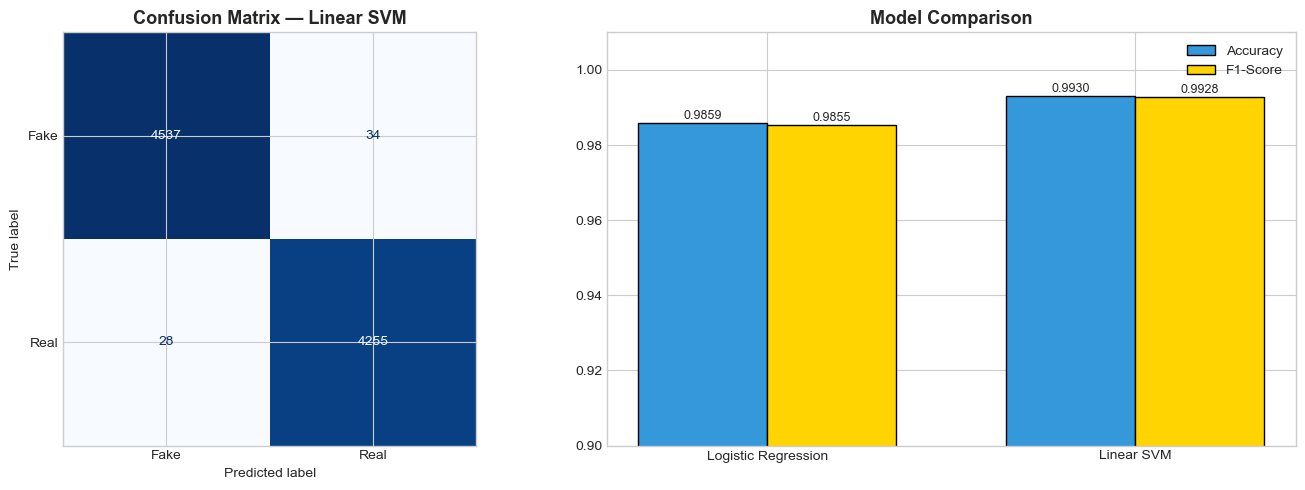

In [26]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, best_pred)
ConfusionMatrixDisplay(cm, display_labels=['Fake', 'Real']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Confusion Matrix — {best_name}', fontsize=13, fontweight='bold')

# --- Model Comparison Bar Chart ---
model_names = list(results.keys())
accuracies  = [results[m]['accuracy'] for m in model_names]
f1_scores   = [results[m]['f1'] for m in model_names]

x = np.arange(len(model_names))
width = 0.35
axes[1].bar(x - width/2, accuracies, width, label='Accuracy', color='#3498db', edgecolor='black')
axes[1].bar(x + width/2, f1_scores,  width, label='F1-Score',  color='#FFD400', edgecolor='black')
axes[1].set_title('Model Comparison', fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names)
axes[1].set_ylim(0.9, 1.01)
axes[1].legend()
for i, (a, f) in enumerate(zip(accuracies, f1_scores)):
    axes[1].text(i - width/2, a + 0.001, f'{a:.4f}', ha='center', fontsize=9)
    axes[1].text(i + width/2, f + 0.001, f'{f:.4f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 8 (BONUS): Word Clouds — Fake vs Real News

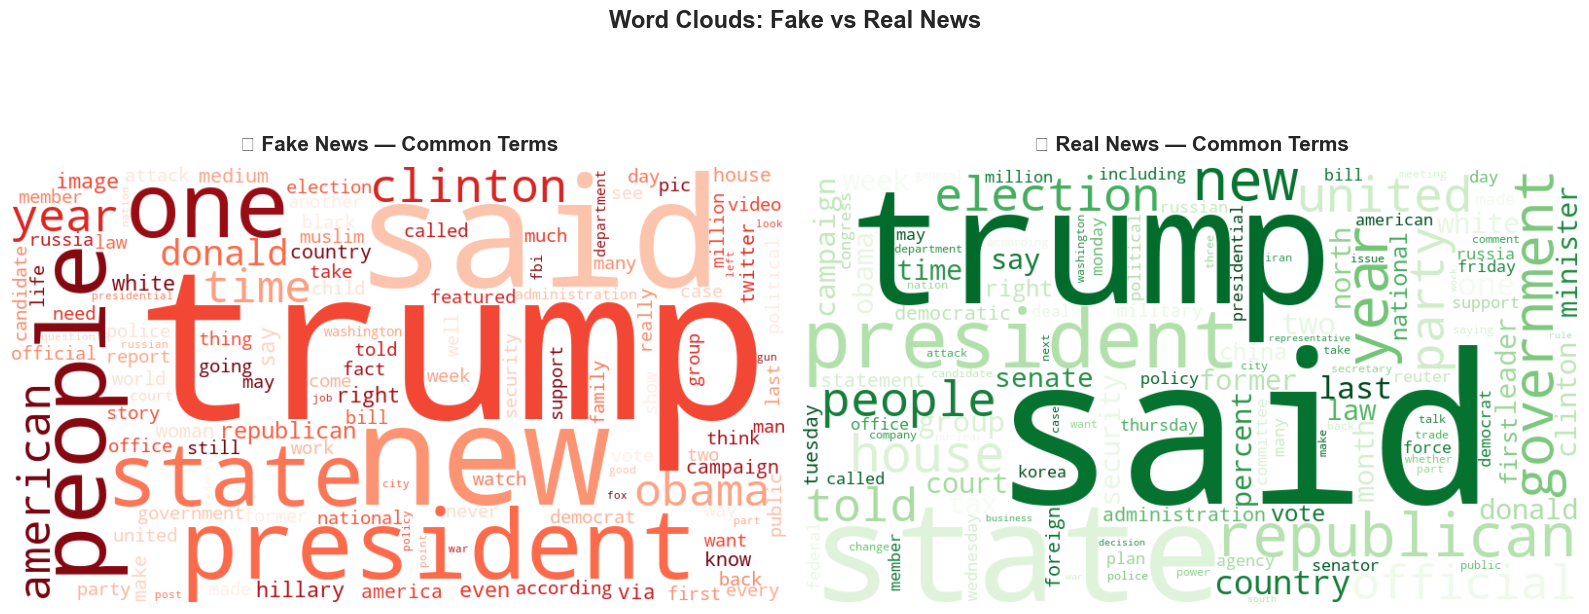

In [27]:
fake_text = ' '.join(df[df['label'] == 0]['content_clean'])
real_text = ' '.join(df[df['label'] == 1]['content_clean'])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, text, title, colormap in [
    (axes[0], fake_text, '🔴 Fake News — Common Terms', 'Reds'),
    (axes[1], real_text, '🟢 Real News — Common Terms', 'Greens')
]:
    wc = WordCloud(
        width=800, height=450,
        background_color='white',
        colormap=colormap,
        max_words=120,
        collocations=False
    ).generate(text)

    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=15, fontweight='bold', pad=12)

plt.suptitle('Word Clouds: Fake vs Real News', fontsize=17, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 9: Predict on New Articles

In [28]:
LABEL_NAMES = {0: '🔴 FAKE', 1: '🟢 REAL'}
best_model = results[best_name]['model']

def predict(articles):
    """Predict whether articles are Fake or Real."""
    cleaned    = [preprocess(a) for a in articles]
    vectorized = tfidf.transform(cleaned)
    preds      = best_model.predict(vectorized)
    return [LABEL_NAMES[p] for p in preds]


test_articles = [
    "NASA confirms discovery of water ice on Mars surface near the polar region.",
    "SHOCKING: Government puts microchips in vaccines to control the population!",
    "Federal Reserve raises interest rates by 0.25% amid inflation concerns.",
    "Scientists HIDE the truth about flat earth — the elite don't want you to know!"
]

predictions = predict(test_articles)

print(f'Using model: {best_name}\n')
print(' Predictions ')
for article, pred in zip(test_articles, predictions):
    print(f'  {pred}  ->  "{article}"')

Using model: Linear SVM

 Predictions 
  🔴 FAKE  ->  "NASA confirms discovery of water ice on Mars surface near the polar region."
  🔴 FAKE  ->  "SHOCKING: Government puts microchips in vaccines to control the population!"
  🟢 REAL  ->  "Federal Reserve raises interest rates by 0.25% amid inflation concerns."
  🔴 FAKE  ->  "Scientists HIDE the truth about flat earth — the elite don't want you to know!"


---
## Step 10: Summary

In [29]:
print('=' * 55)
print('      FAKE NEWS DETECTION -> SUMMARY')
print('=' * 55)
print(f'Dataset     : ErfanMoosaviMonazzah/fake-news-detection-dataset-English (HF)')
print(f'Total rows  : {len(df):,}')
print(f'Features    : TF-IDF (unigrams + bigrams, 30k terms)')
print(f'Preprocessing: lowercase, URL removal, stopwords, lemmatize')
print()
print(' Results ')
print('\n')
for name, v in results.items():
    flag = '' if name == best_name else '  '
    print(f'{flag} {name:<25} Accuracy: {v["accuracy"]:.4f}  F1: {v["f1"]:.4f}')
print('=' * 55)

      FAKE NEWS DETECTION -> SUMMARY
Dataset     : ErfanMoosaviMonazzah/fake-news-detection-dataset-English (HF)
Total rows  : 44,267
Features    : TF-IDF (unigrams + bigrams, 30k terms)
Preprocessing: lowercase, URL removal, stopwords, lemmatize

 Results 


   Logistic Regression       Accuracy: 0.9859  F1: 0.9855
 Linear SVM                Accuracy: 0.9930  F1: 0.9928
